# Ham Veri Keşfi
Air Quality Data in India veri setindeki 5 CSV dosyasının incelenmesi ve çalışılacak şehrin seçimi.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
RAW = Path("../data/raw")
print(RAW.resolve())

D:\air_quality_project\hava-kalitesi-tahmini\data\raw


In [2]:
for f in sorted(RAW.glob("*.csv")):
    print(f"{f.name:20s} {f.stat().st_size / 1e6:8.1f} MB")

city_day.csv              2.6 MB
city_hour.csv            65.6 MB
station_day.csv           8.6 MB
station_hour.csv        219.7 MB
stations.csv              0.0 MB


In [3]:
def incele(df, tarih_kolonu=None):
    print("Satır, sütun:", df.shape)
    if tarih_kolonu:
        print("Tarih aralığı:", df[tarih_kolonu].min(), "→", df[tarih_kolonu].max())
    tablo = (df.isna().mean() * 100).round(1).to_frame("bos_%")
    tablo["tip"] = df.dtypes
    display(tablo.sort_values("bos_%", ascending=False))
    display(df.head(3))

In [4]:
city_day = pd.read_csv(RAW / "city_day.csv", parse_dates=["Date"])
incele(city_day, "Date")

Satır, sütun: (29531, 16)
Tarih aralığı: 2015-01-01 00:00:00 → 2020-07-01 00:00:00


,bos_%,tip
Xylene,61.3,float64
PM10,37.7,float64
NH3,35.0,float64
Toluene,27.2,float64
Benzene,19.0,float64
AQI,15.9,float64
AQI_Bucket,15.9,str
PM2.5,15.6,float64
NOx,14.2,float64
O3,13.6,float64


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN


In [5]:
city_hour = pd.read_csv(RAW / "city_hour.csv", parse_dates=["Datetime"])
incele(city_hour, "Datetime")

Satır, sütun: (707875, 16)
Tarih aralığı: 2015-01-01 01:00:00 → 2020-07-01 00:00:00


,bos_%,tip
Xylene,64.4,float64
PM10,41.9,float64
NH3,38.5,float64
Toluene,31.2,float64
Benzene,23.1,float64
PM2.5,20.5,float64
SO2,18.4,float64
O3,18.3,float64
AQI_Bucket,18.2,str
AQI,18.2,float64


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,NaN,NaN,1.00,40.01,36.37,NaN,1.00,122.07,NaN,0.0,0.0,0.0,NaN,NaN
1,Ahmedabad,2015-01-01 02:00:00,NaN,NaN,0.02,27.75,19.73,NaN,0.02,85.90,NaN,0.0,0.0,0.0,NaN,NaN
2,Ahmedabad,2015-01-01 03:00:00,NaN,NaN,0.08,19.32,11.08,NaN,0.08,52.83,NaN,0.0,0.0,0.0,NaN,NaN


In [6]:
station_day = pd.read_csv(RAW / "station_day.csv", parse_dates=["Date"])
incele(station_day, "Date")

Satır, sütun: (108035, 16)
Tarih aralığı: 2015-01-01 00:00:00 → 2020-07-01 00:00:00


,bos_%,tip
Xylene,78.8,float64
NH3,44.5,float64
PM10,39.5,float64
Toluene,35.8,float64
Benzene,29.1,float64
O3,23.7,float64
SO2,23.3,float64
PM2.5,20.0,float64
AQI_Bucket,19.4,str
AQI,19.4,float64


,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate


In [7]:
stations = pd.read_csv(RAW / "stations.csv")
incele(stations)
print(stations["Status"].value_counts(dropna=False))

Satır, sütun: (230, 5)


,bos_%,tip
Status,42.2,str
StationId,0.0,str
StationName,0.0,str
City,0.0,str
State,0.0,str


,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN


Status
Active      131
NaN          97
Inactive      2
Name: count, dtype: int64


In [8]:
station_hour = pd.read_csv(RAW / "station_hour.csv", nrows=100_000, parse_dates=["Datetime"])
incele(station_hour, "Datetime")

Satır, sütun: (100000, 16)
Tarih aralığı: 2015-06-01 15:00:00 → 2020-07-01 00:00:00


,bos_%,tip
NH3,39.2,float64
Xylene,39.0,float64
PM10,38.4,float64
Toluene,27.5,float64
PM2.5,26.7,float64
AQI_Bucket,25.4,str
AQI,25.4,float64
SO2,23.7,float64
NO2,22.7,float64
NO,22.3,float64


,StationId,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24 17:00:00,60.5,98.00,2.35,30.80,18.25,8.50,0.1,11.85,126.40,0.1,6.10,0.10,NaN,NaN
1,AP001,2017-11-24 18:00:00,65.5,111.25,2.70,24.20,15.07,9.77,0.1,13.17,117.12,0.1,6.25,0.15,NaN,NaN
2,AP001,2017-11-24 19:00:00,80.0,132.00,2.10,25.18,15.15,12.02,0.1,12.08,98.98,0.2,5.98,0.18,NaN,NaN


In [9]:
st = station_day.merge(stations[["StationId", "City"]], on="StationId", how="left")
print("İstasyon verisi olan şehir sayısı:", st["City"].nunique())
print("city_day'deki şehir sayısı:", city_day["City"].nunique())
st.groupby("City")["StationId"].nunique().sort_values(ascending=False).head(10)

İstasyon verisi olan şehir sayısı: 26
city_day'deki şehir sayısı: 26


City
Delhi        38
Bengaluru    10
Mumbai       10
Kolkata       7
Hyderabad     6
Patna         6
Lucknow       5
Gurugram      4
Chennai       4
Jaipur        3
Name: StationId, dtype: int64

In [10]:
sehir, gun = "Delhi", "2019-01-15"
ist = st[(st["City"] == sehir) & (st["Date"] == gun)]
print("O gün veri veren istasyon sayısı:", ist["PM2.5"].notna().sum())
print("İstasyonların PM2.5 ortalaması:", round(ist["PM2.5"].mean(), 2))
print("city_day'deki değer:", city_day.loc[(city_day["City"] == sehir) & (city_day["Date"] == gun), "PM2.5"].values)

O gün veri veren istasyon sayısı: 36
İstasyonların PM2.5 ortalaması: 135.33
city_day'deki değer: [134.57]


In [11]:
ozet = city_day.groupby("City").agg(
    baslangic=("Date", "min"),
    bitis=("Date", "max"),
    gun_sayisi=("Date", "count"),
    pm25_doluluk=("PM2.5", lambda s: s.notna().mean().round(2)),
    pm10_doluluk=("PM10", lambda s: s.notna().mean().round(2)),
).sort_values(["pm25_doluluk", "gun_sayisi"], ascending=False)
ozet

,baslangic,bitis,gun_sayisi,pm25_doluluk,pm10_doluluk
City,,,,,
Delhi,2015-01-01,2020-07-01,2009,1.00,0.96
Guwahati,2019-02-16,2020-07-01,502,1.00,1.00
Kochi,2020-01-22,2020-07-01,162,1.00,1.00
Jaipur,2017-06-14,2020-07-01,1114,0.99,0.99
Coimbatore,2019-06-12,2020-07-01,386,0.98,0.98
Ernakulam,2020-01-22,2020-07-01,162,0.98,0.98
Aizawl,2020-03-11,2020-07-01,113,0.98,0.99
Bhopal,2019-09-17,2020-07-01,289,0.97,0.97
Thiruvananthapuram,2017-06-16,2020-07-01,1112,0.96,0.97


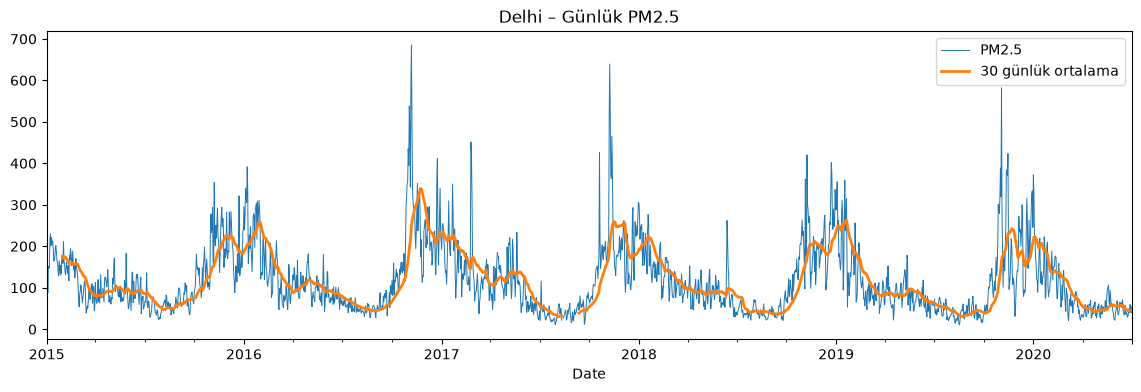

In [12]:
sehir = "Delhi"   # hücre 12'ye göre kendi seçiminizle değiştirin
s = city_day[city_day["City"] == sehir].set_index("Date")["PM2.5"]

fig, ax = plt.subplots(figsize=(14, 4))
s.plot(ax=ax, linewidth=0.7)
s.rolling(30).mean().plot(ax=ax, linewidth=2, label="30 günlük ortalama")
ax.set_title(f"{sehir} – Günlük PM2.5")
ax.legend()
plt.show()